   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Median Tip: 2.9
tip_category
0    122
1    122
Name: count, dtype: int64


ValueError: could not convert string to float: 'Male'

In [14]:


import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


tips = sns.load_dataset('tips')


median_tip = tips['tip'].median()

tips['tip_category'] = tips['tip'].apply(
    lambda x: 1 if x >= median_tip else 0
)


data = tips.copy()


for col in data.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])


X = data.drop(['tip', 'tip_category'], axis=1)
y = data['tip_category']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7346938775510204

Confusion Matrix:
[[23  8]
 [ 5 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.62      0.72      0.67        18

    accuracy                           0.73        49
   macro avg       0.72      0.73      0.72        49
weighted avg       0.75      0.73      0.74        49



Accuracy: 0.7346938775510204

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.62      0.72      0.67        18

    accuracy                           0.73        49
   macro avg       0.72      0.73      0.72        49
weighted avg       0.75      0.73      0.74        49



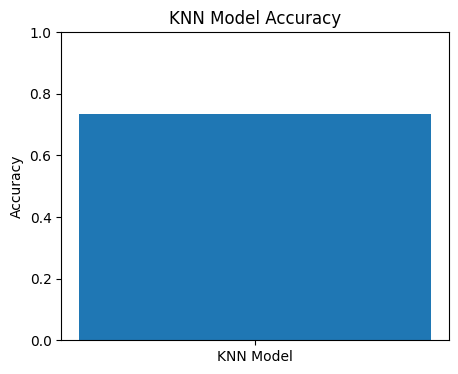

In [18]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

tips = sns.load_dataset('tips')

median_tip = tips['tip'].median()

tips['tip_category'] = tips['tip'].apply(
    lambda x: 1 if x >= median_tip else 0
)

data = tips.copy()

for col in data.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data.drop(['tip', 'tip_category'], axis=1)
y = data['tip_category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
plt.bar(['KNN Model'], [accuracy])
plt.title('KNN Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

